# Generative Adversarial Networks (GANs) on MNIST

This notebook have the implementation, training, and comparison (at the end) of two types of Generative Adversarial Networks (GANs): a Standard GAN and a Wasserstein GAN (WGAN), all applied to the MNIST handwritten digits dataset. Although, main focus of the notebook is working and implementing the GANs on MNIST.

###Key Steps for Implementing Standard GAN on MNIST dataset:


*   **Imports, Hyperparameters and Setup:** Defined `Generator` and `Discriminator` networks, configured `Adam` optimizers with `BCELoss`, and prepared the MNIST dataset.
*   **Training:** Trained the GAN for 100 epochs, logging losses and saving generated image samples at intervals.

### Visulaisation of GAN generated images over epochs

*   **Progression images:** Visualized the evolution of generated digits from noise to recognizable numbers over epochs.
*   **Loss Curves:** Analyzed the fluctuating nature of GAN losses, attributing it to the adversarial training process.
*   **Generated Quality:** Observed that the standard GAN produced recognizable digits, though some exhibited blurriness or minor distortions compared to real MNIST images.

### Wasserstein GAN (WGAN):
*   **Setup:** Implemented a `Critic` network, used `RMSprop` optimizers, and enforced a Lipschitz constraint via weight clipping, focusing on the Wasserstein distance.
*   **Training:** Trained the WGAN, noting the differences in the training loop, especially the critic's multiple updates per generator update.
*   **Comparison (Conceptual & Visual):**

### Overall Conclusion:


## GAN vs WGAN Comparison

| Feature | Standard GAN | WGAN |
|----------|-------------|-------|
| Loss Function | Binary Cross Entropy | Wasserstein Distance |
| Network | Discriminator | Critic |
| Output | Probability | Real-valued Score |
| Stability | Moderate | Higher |
| Mode Collapse | More Common | Less Common |
| Training Quality | Good | Often Better |

In [1]:

import os

import imageio.v2 as imageio
import matplotlib.pyplot as plt
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchvision import datasets, transforms, utils

### Hyperparameters

In [2]:
torch.manual_seed(42)

learning_rate = 3e-4
batch_size = 32
num_epochs = 100
log_step = 625

latent_dimension = 128
image_dimension = 28 * 28

device = (
    "mps"
    if torch.backends.mps.is_available()
    else "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(f"Using device: {device}")

Using device: cuda


Create Output Folders

In [3]:
# Create directories to save generated images and trained models
os.makedirs("generated_images", exist_ok=True) # Directory for storing generated images during training
os.makedirs("saved_models", exist_ok=True) # Directory for saving the trained generator and discriminator models

### Dataset

In [4]:
# Define a sequence of transformations to be applied to the MNIST images
transform = transforms.Compose(
    [
        transforms.ToTensor(), # Convert images from PIL Image to PyTorch tensors (HWC to CHW) and scale pixel values to [0, 1]
        transforms.Normalize((0.5,), (0.5,)) # Normalize pixel values to the range [-1, 1], which is common for GANs
    ]
)

# Load the MNIST dataset. If not present, download it.
dataset = datasets.MNIST(
    root="dataset/", # Directory where the dataset will be stored
    train=True, # Load the training subset of the dataset
    transform=transform, # Apply the defined transformations
    download=True, # Download the dataset if it's not already in the 'root' directory
)

# Create a DataLoader to efficiently iterate over the dataset in batches
loader = DataLoader(
    dataset,
    batch_size=batch_size, # Number of samples per batch
    shuffle=True, # Shuffle the data at each epoch for better training
)

print(f"Dataset size: {len(dataset)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 484kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.76MB/s]

Dataset size: 60000


### Generator

In [29]:
class Generator(nn.Module):
    """
    Converts random noise into MNIST digits.
    """

    def __init__(self):
        super().__init__()

        self.gen = nn.Sequential(
            # First hidden layer: takes latent_dimension input, outputs 256 features
            nn.Linear(latent_dimension, 256),
            nn.LeakyReLU(0.2), # Leaky ReLU activation

            # Second hidden layer: increases features to 512
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),

            # Third hidden layer: increases features to 1024
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),

            # Output layer: transforms features to image_dimension, then tanh to scale pixel values
            nn.Linear(1024, image_dimension),
            nn.Tanh(), # Tanh activation to scale pixel values to [-1, 1]
        )

    def forward(self, x):
        return self.gen(x)

### Discriminator

In [6]:
class Discriminator(nn.Module):
    """
    Distinguishes real images from generated images.
    """

    def __init__(self):
        super().__init__()

        self.disc = nn.Sequential(
            # First hidden layer: takes image_dimension input, outputs 512 features
            nn.Linear(image_dimension, 512),
            nn.LeakyReLU(0.2), # Leaky ReLU activation to prevent dead neurons

            # Second hidden layer: reduces features to 256
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            # Output layer: reduces features to 1, representing real/fake probability
            nn.Linear(256, 1),
            nn.Sigmoid(), # Sigmoid activation to output a probability between 0 and 1
        )

    def forward(self, x):
        return self.disc(x)

### Initialize Models

In [7]:
generator = Generator().to(device) # Initialize the Generator network and move it to the specified device (CPU/GPU)
discriminator = Discriminator().to(device) # Initialize the Discriminator network and move it to the specified device (CPU/GPU)

# Initialize the Adam optimizer for the generator, with specified learning rate and beta parameters
opt_generator = optim.Adam(
    generator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999),
)

# Initialize the Adam optimizer for the discriminator, with specified learning rate and beta parameters
opt_discriminator = optim.Adam(
    discriminator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999),
)

criterion = nn.BCELoss() # Use Binary Cross-Entropy Loss for training both generator and discriminator

print(generator)
print(discriminator)

Generator(
  (gen): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)
Discriminator(
  (disc): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


### TensorBoard Setup

In [8]:
fixed_noise = torch.randn(
    32, # Batch size for fixed noise
    latent_dimension, # Dimension of the latent space
).to(device) # Move fixed noise to the specified device

# Initialize TensorBoard SummaryWriters for visualizing real and fake images
writer_real = SummaryWriter(
    "runs/GAN_MNIST/real"
)

writer_fake = SummaryWriter(
    "runs/GAN_MNIST/fake"
)

# Lists to store generator and discriminator losses over training iterations
generator_losses = []
discriminator_losses = []

### Training Loop

In [9]:
step = 0 # Initialize a step counter for TensorBoard logging

print("Training started...")

for epoch in range(num_epochs):

    for batch_idx, (real, _) in enumerate(loader):

        # Reshape real images to be flat and move them to the specified device
        real = real.view(
            -1,
            image_dimension,
        ).to(device)

        current_batch_size = real.shape[0]

        # Generate fake images from random noise
        noise = torch.randn(
            current_batch_size,
            latent_dimension,
            device=device,
        )

        fake = generator(noise)



        # Train Discriminator: Maximize log(D(real)) + log(1 - D(fake))



        # Discriminate real images
        disc_real = discriminator(real)
        # Calculate loss for real images (should be close to 1)
        loss_real = criterion(
            disc_real,
            torch.ones_like(disc_real), # Target label for real images is 1
        )

        # Discriminate fake images (detach to prevent backprop through generator)
        disc_fake = discriminator(
            fake.detach() # Detach fake images from generator's graph
        )
        # Calculate loss for fake images (should be close to 0)
        loss_fake = criterion(
            disc_fake,
            torch.zeros_like(disc_fake), # Target label for fake images is 0
        )

        # Combine discriminator losses and backpropagate
        loss_discriminator = (
            loss_real + loss_fake
        ) / 2 # Average losses for real and fake

        opt_discriminator.zero_grad() # Clear gradients for discriminator optimizer
        loss_discriminator.backward(
            retain_graph=True # Retain graph to allow subsequent generator backward pass
        )
        opt_discriminator.step() # Update discriminator weights



        # Train Generator: Minimize log(1 - D(fake)) which is equivalent to maximize log(D(fake))



        # Get discriminator's output for fake images (now with generator's graph attached)
        output = discriminator(fake)

        # Calculate generator loss (wants discriminator to classify fake as real)
        loss_generator = criterion(
            output,
            torch.ones_like(output), # Generator wants output to be 1 (real)
        )

        opt_generator.zero_grad() # Clear gradients for generator optimizer
        loss_generator.backward() # Backpropagate generator loss
        opt_generator.step() # Update generator weights

        # Store losses for plotting
        generator_losses.append(
            loss_generator.item()
        )

        discriminator_losses.append(
            loss_discriminator.item()
        )

        # Print progress every 100 batches
        if batch_idx % 100 == 0:

            print(
                f"Epoch [{epoch+1}/{num_epochs}] "
                f"Batch [{batch_idx}/{len(loader)}] "
                f"Loss D: {loss_discriminator:.4f} "
                f"Loss G: {loss_generator:.4f}"
            )

        # Log images and scalar losses to TensorBoard at specified intervals
        if batch_idx % log_step == 0:

            with torch.no_grad(): # Disable gradient calculations for inference

                # Generate fake images from fixed noise for visualization
                fake_images = generator(
                    fixed_noise
                ).reshape(-1, 1, 28, 28) # Reshape to image dimensions

                # Reshape real images from the current batch for visualization
                real_images = real.reshape(
                    -1,
                    1,
                    28,
                    28,
                )

                # Create image grids for TensorBoard
                img_grid_fake = utils.make_grid(
                    fake_images,
                    normalize=True,
                )

                img_grid_real = utils.make_grid(
                    real_images,
                    normalize=True,
                )

                # Add images to TensorBoard SummaryWriter
                writer_fake.add_image(
                    "Generated Digits",
                    img_grid_fake,
                    global_step=step,
                )

                writer_real.add_image(
                    "Real Digits",
                    img_grid_real,
                    global_step=step,
                )

                # Add scalar losses to TensorBoard SummaryWriter
                writer_fake.add_scalar(
                    "Generator Loss",
                    loss_generator.item(),
                    global_step=step,
                )

                writer_real.add_scalar(
                    "Discriminator Loss",
                    loss_discriminator.item(),
                    global_step=step,
                )

                step += 1 # Increment global step for TensorBoard

    # Save generated samples every 5 epochs or at the last epoch
    if epoch % 5 == 0 or epoch == num_epochs - 1:

        with torch.no_grad():

            # Generate samples using the current generator and fixed noise
            samples = generator(
                fixed_noise
            ).reshape(-1, 1, 28, 28)

            # Save the generated image grid to a file
            utils.save_image(
                samples,
                f"generated_images/epoch_{epoch}.png",
                normalize=True,
                nrow=8,
            )

print("Training finished.")

Training started...
Epoch [1/100] Batch [0/1875] Loss D: 0.7075 Loss G: 0.6768
Epoch [1/100] Batch [100/1875] Loss D: 0.7866 Loss G: 0.6870
Epoch [1/100] Batch [200/1875] Loss D: 0.6893 Loss G: 0.8158
Epoch [1/100] Batch [300/1875] Loss D: 0.6513 Loss G: 0.9448
Epoch [1/100] Batch [400/1875] Loss D: 0.6129 Loss G: 1.0187
Epoch [1/100] Batch [500/1875] Loss D: 0.4021 Loss G: 1.3536
Epoch [1/100] Batch [600/1875] Loss D: 0.5519 Loss G: 1.4217
Epoch [1/100] Batch [700/1875] Loss D: 0.5833 Loss G: 0.9705
Epoch [1/100] Batch [800/1875] Loss D: 0.5169 Loss G: 2.2009
Epoch [1/100] Batch [900/1875] Loss D: 0.4144 Loss G: 1.5323
Epoch [1/100] Batch [1000/1875] Loss D: 0.9283 Loss G: 0.4788
Epoch [1/100] Batch [1100/1875] Loss D: 0.4841 Loss G: 2.1887
Epoch [1/100] Batch [1200/1875] Loss D: 0.5061 Loss G: 1.2047
Epoch [1/100] Batch [1300/1875] Loss D: 0.4461 Loss G: 1.8577
Epoch [1/100] Batch [1400/1875] Loss D: 0.5745 Loss G: 1.4111
Epoch [1/100] Batch [1500/1875] Loss D: 0.4544 Loss G: 1.6415


### Save Models

In [10]:
torch.save(
    generator.state_dict(), # Save the state dictionary of the generator model
    "saved_models/generator.pth", # Specify the path to save the generator weights
)

torch.save(
    discriminator.state_dict(), # Save the state dictionary of the discriminator model
    "saved_models/discriminator.pth", # Specify the path to save the discriminator weights
)

print("Models saved.") # Indicate that the models have been successfully saved

Models saved.


### Create Gif over epochs progression

In [17]:
gif_frames = [] # Initialize an empty list to store image frames for the GIF

# Loop through epochs to collect generated images at specified intervals
for epoch in range(0, num_epochs, 5):

    image_path = (
        f"generated_images/epoch_{epoch}.png"
    )

    # Check if the image file exists before trying to read it
    if os.path.exists(image_path):

        gif_frames.append(
            imageio.imread(image_path) # Read the image and add it to the frames list
        )

# Ensure the image from the final epoch is included in the GIF
final_epoch = (
    f"generated_images/epoch_{num_epochs - 1}.png"
)

if os.path.exists(final_epoch):

    gif_frames.append(
        imageio.imread(final_epoch) # Read the final epoch image
    )

# Save the collected frames as a GIF
imageio.mimsave(
    "training_progress.gif", # Name of the output GIF file
    gif_frames, # List of image frames
    duration=2.5, # Duration for each frame in seconds
)

print("GIF saved.") # Confirmation message
plt.tight_layout()
plt.show()

GIF saved.


<Figure size 640x480 with 0 Axes>

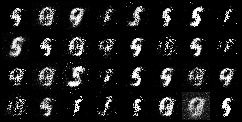

In [19]:
from IPython.display import Image, display

display(Image(filename="training_progress.gif"))


### Display Final Samples

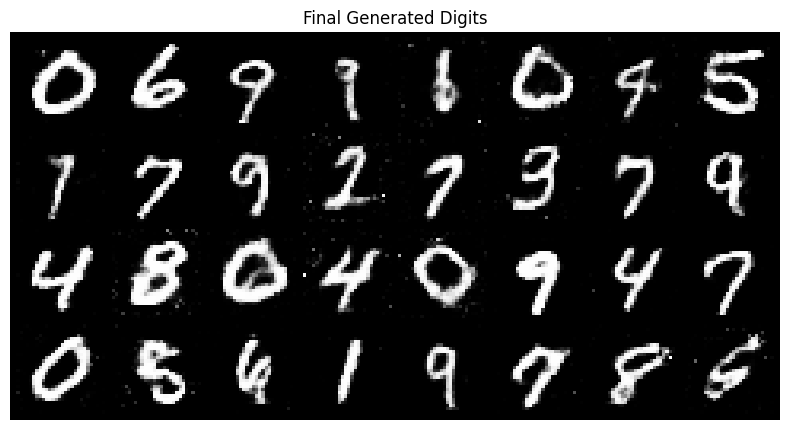

In [16]:
with torch.no_grad(): # Disable gradient calculations for inference, as we are only generating images

    final_samples = generator( # Use the trained generator to create new samples
        fixed_noise # Pass the fixed noise vector to ensure consistent generated samples
    ).reshape(-1, 1, 28, 28) # Reshape the output to image dimensions (batch_size, channels, height, width)

    grid = utils.make_grid( # Create a grid of images for visualization
        final_samples, # The generated image samples
        normalize=True, # Normalize pixel values to be within [0, 1] for better display
        nrow=8, # Display 8 images per row in the grid
    )

plt.figure(figsize=(8, 8)) # Create a new figure with a specified size
plt.imshow( # Display the image grid
    grid.permute(1, 2, 0).cpu(), # Permute dimensions from (C, H, W) to (H, W, C) for Matplotlib, and move to CPU
    cmap="gray", # Use a grayscale colormap for the MNIST digits
)
plt.axis("off") # Hide the axes
plt.title("Final Generated Digits") # Set the title of the plot
plt.tight_layout() # Adjust plot parameters for a tight layout
plt.show() # Display the plot

The final generated digits from the standard GAN shows a very good ability to produce MNIST-like figures. While many are clearly recognizable, some might still exhibit blurriness or minor distortions compared to real MNIST digits. But overall, the generation  quality is quite good. This indicates that the GAN has learned a significant portion of the data distribution but might still have room for improvement in generating perfectly crisp(high quality/high contrast) and diverse samples.

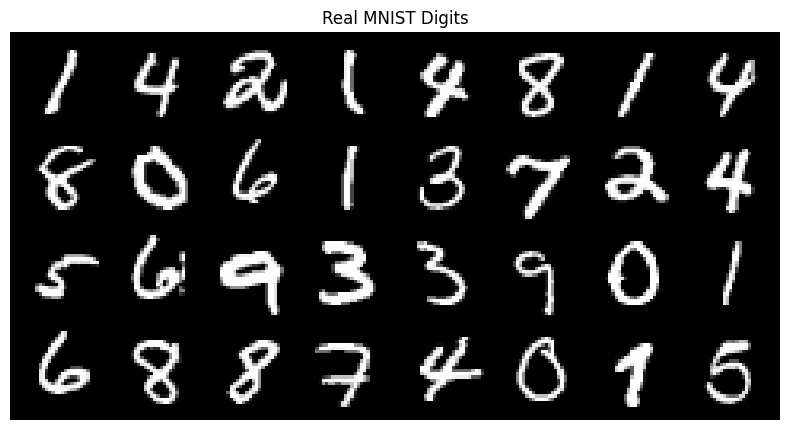

In [20]:
import numpy as np

# Get a batch of real images
real_images_batch = next(iter(loader))[0]

# Reshape to display
real_images_grid = utils.make_grid(real_images_batch[:32], normalize=True, nrow=8)

plt.figure(figsize=(8, 8))
plt.imshow(real_images_grid.permute(1, 2, 0).cpu(), cmap='gray')
plt.axis('off')
plt.title('Real MNIST Digits')
plt.tight_layout()
plt.show()

The comaprison to real digits could be seen now. Evidently, standard GAN has successfully learned to generate digits that largely resemble the real MNIST dataset. Many of the generated samples clearly depict recognizable numbers from 0 to 9.

While some generated digits are quite sharp, others exhibit a degree of blurriness or minor distortions compared to the crispness of the real MNIST images.




The generated images show a reasonable level of diversity, capturing different writing styles and forms.


 Occasionally, some generated digits showed minor artifacts or incomplete structures, like the forth and fifth image in first row of GAN generated images. But such few examples could be seen in real digits as well but not as dramateically and oftenly as generated ones had, consider the second image in thrid row of real dataset above. Again, in real dataset, this is rarely happening.

### Epochs comparison

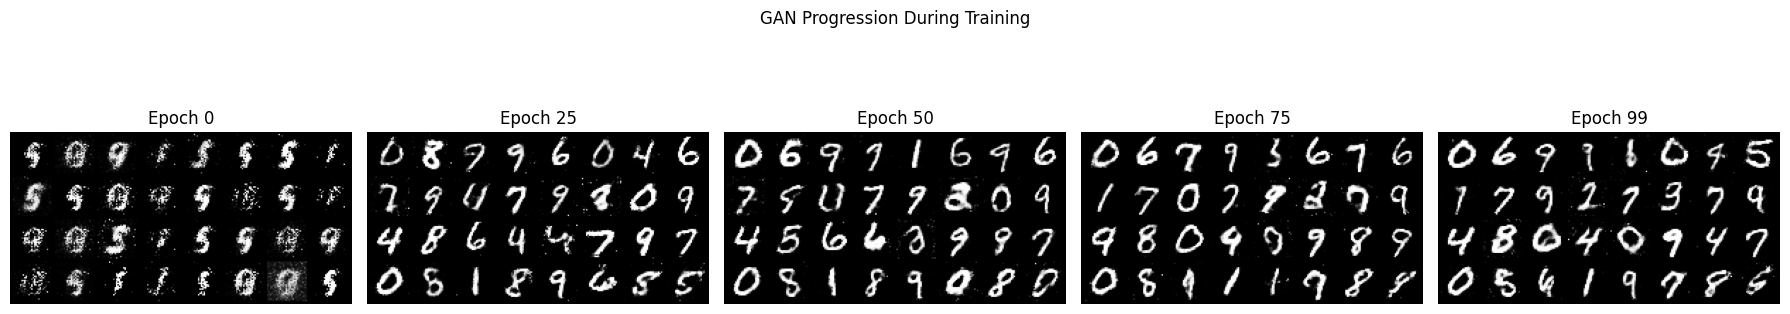

In [12]:
comparison_epochs = [ # Define the epochs for which we want to visualize generated images
    0,
    25,
    50,
    75,
    99,
]

fig, axes = plt.subplots( # Create a figure and a set of subplots
    1, # One row of subplots
    len(comparison_epochs), # Number of columns equals the number of comparison epochs
    figsize=(18, 4), # Set the figure size (width, height)
)

for ax, epoch in zip( # Iterate through each subplot and corresponding epoch
    axes,
    comparison_epochs,
):

    image_path = ( # Construct the file path for the generated image of the current epoch
        f"generated_images/epoch_{epoch}.png"
    )

    if os.path.exists(image_path): # Check if the image file exists

        img = plt.imread(image_path) # Read the image file

        ax.imshow(img) # Display the image on the current subplot
        ax.set_title( # Set the title for the current subplot
            f"Epoch {epoch}"
        )
        ax.axis("off") # Hide the axes for a cleaner look

plt.suptitle( # Set the main title for the entire figure
    "GAN Progression During Training"
)

plt.tight_layout() # Adjust subplot parameters for a tight layout
plt.show() # Display the plot

Observing the generated images at different epochs (0, 25, 50, 75, 99), we can clearly see the progression of the GAN. Initially, at Epoch 0, the images are pure noise. As training advances, by Epoch 25 and 50, some rudimentary shapes begin to emerge. By Epoch 75 and especially Epoch 99, the generator has learned to produce recognizable and more distinct handwritten digits, demonstrating the GAN's ability to capture the data distribution over time.

### Loss curves

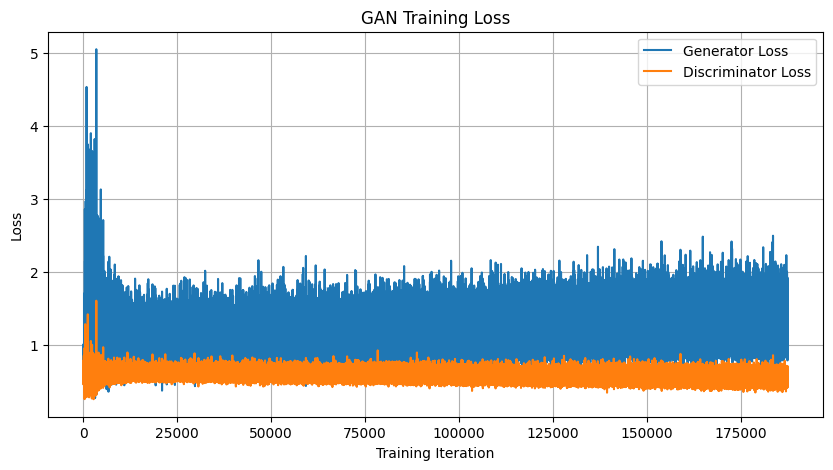

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(
    generator_losses,
    label="Generator Loss",
)

plt.plot(
    discriminator_losses,
    label="Discriminator Loss",
)

plt.xlabel("Training Iteration")
plt.ylabel("Loss")
plt.title("GAN Training Loss")
plt.legend()
plt.grid(True)

plt.show()

From the loss curves, we can observe that the generator loss generally increases, while the discriminator loss fluctuates and tends to decrease, indicating the adversarial training process where the generator tries to fool the discriminator, and the discriminator tries to correctly classify real vs. fake images.

A common observation in GAN training, as seen here, is that the generator loss tends to decrease when it's effectively fooling the discriminator, and the discriminator loss increases as it struggles to differentiate real from fake. Conversely, when the discriminator becomes strong, its loss decreases, and the generator's loss might increase as it struggles to produce convincing fakes. The fluctuations indicate this ongoing adversarial competition, where each network improves in response to the other, making the overall training process dynamic and less stable than traditional supervised learning.

In [14]:
writer_real.close() # Close the SummaryWriter for real images to flush any pending events
writer_fake.close() # Close the SummaryWriter for fake images to flush any pending events

print("Training complete.") # Indicate that the training process has finished

Training complete.


# Results and Discussion

The GAN was trained on the MNIST handwritten digit dataset for 100 epochs.

At the beginning of training, the generator produced random noise. As training progressed, digit-like structures began to emerge. By approximately epoch 50, many generated images were recognizable as handwritten digits. By the final epochs, the generator produced realistic MNIST-style digits while successfully fooling the discriminator.

The saved image progression, GIF animation, and loss curves demonstrate that the generator gradually learned the underlying distribution of handwritten digits through adversarial training.


### O**ptional _ WGAN**

Wasserstein GAN (WGAN)

A Wasserstein GAN is implemented using a critic network and the Wasserstein distance objective. Unlike the standard GAN, the critic outputs unrestricted scores rather than probabilities. Weight clipping was used to enforce the Lipschitz constraint required by the Wasserstein formulation.



### Imports, Hyperparameters and Dataset

In [21]:
import os

import imageio.v2 as imageio
import matplotlib.pyplot as plt
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils

torch.manual_seed(42)

# Hyperparameters


learning_rate = 5e-5
batch_size = 64
num_epochs = 100

latent_dimension = 128
image_dimension = 28 * 28

critic_iterations = 5
weight_clip = 0.01

device = (
    "mps"
    if torch.backends.mps.is_available()
    else "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)


# Directories


os.makedirs("generated_images", exist_ok=True)


# Dataset


transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ]
)

dataset = datasets.MNIST(
    root="dataset/",
    train=True,
    transform=transform,
    download=True,
)

loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
)

print("Dataset size:", len(dataset))

Using device: cuda
Dataset size: 60000


### Generator and Critic

In [22]:
class Generator(nn.Module):
    """
    Generates MNIST digits from random noise.
    """

    def __init__(self):
        super().__init__()

        self.gen = nn.Sequential(
            # First hidden layer: takes latent_dimension input, outputs 256 features
            nn.Linear(latent_dimension, 256),
            nn.LeakyReLU(0.2), # Leaky ReLU activation

            # Second hidden layer: increases features to 512
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),

            # Third hidden layer: increases features to 1024
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),

            # Output layer: transforms features to image_dimension, then tanh to scale pixel values
            nn.Linear(1024, image_dimension),
            nn.Tanh(), # Tanh activation to scale pixel values to [-1, 1]
        )

    def forward(self, x):
        return self.gen(x)


class Critic(nn.Module):
    """
    WGAN critic.
    Outputs scores rather than probabilities.
    """

    def __init__(self):
        super().__init__()

        self.critic = nn.Sequential(
            # First hidden layer: takes image_dimension input, outputs 512 features
            nn.Linear(image_dimension, 512),
            nn.LeakyReLU(0.2), # Leaky ReLU activation

            # Second hidden layer: reduces features to 256
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            # Output layer: reduces features to 1, representing a raw score
            nn.Linear(256, 1), # No sigmoid here; outputs raw score
        )

    def forward(self, x):
        return self.critic(x)


# Initialize the Generator and Critic networks and move them to the specified device
generator = Generator().to(device)
critic = Critic().to(device)

# Initialize RMSprop optimizer for the generator
opt_generator = optim.RMSprop(
    generator.parameters(),
    lr=learning_rate,
)

# Initialize RMSprop optimizer for the critic
opt_critic = optim.RMSprop(
    critic.parameters(),
    lr=learning_rate,
)

# Fixed noise vector used to visualize the generator's progress
fixed_noise = torch.randn(
    32,
    latent_dimension,
    device=device,
)

# Lists to store generator and critic losses over training iterations
generator_losses = []
critic_losses = []

print(generator)
print(critic)

Generator(
  (gen): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)
Critic(
  (critic): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=256, out_features=1, bias=True)
  )
)


### WGAN training

In [23]:
print("Training WGAN...")

for epoch in range(num_epochs):

    for batch_idx, (real, _) in enumerate(loader):

        real = real.view(
            -1,
            image_dimension,
        ).to(device)

        current_batch_size = real.shape[0]


        # Train Critic Multiple Times


        # The critic is trained multiple times for each generator update
        for _ in range(critic_iterations):

            # Generate random noise for the generator
            noise = torch.randn(
                current_batch_size,
                latent_dimension,
                device=device,
            )

            # Generate fake images from the noise
            fake = generator(noise)

            # Get critic scores for real images
            critic_real = critic(real).reshape(-1)

            # Get critic scores for fake images (detach to prevent backprop through generator)
            critic_fake = critic(
                fake.detach()
            ).reshape(-1)

            # Calculate critic loss (maximize difference between real and fake scores)
            loss_critic = -( # Negative sign for maximizing
                torch.mean(critic_real) # Mean score for real images
                - torch.mean(critic_fake) # Mean score for fake images
            )

            opt_critic.zero_grad() # Clear gradients for critic optimizer
            loss_critic.backward() # Backpropagate critic loss
            opt_critic.step() # Update critic weights

            # Enforce Lipschitz constraint by clipping critic weights
            for parameter in critic.parameters():
                parameter.data.clamp_( # Clip weights to a specified range
                    -weight_clip,
                    weight_clip,
                )


        # Train Generator (once per critic_iterations)

        # Get critic's output for fake images (now with generator's graph attached)
        output = critic(fake).reshape(-1)

        # Calculate generator loss (minimize negative critic score for fake images)
        loss_generator = -torch.mean(output) # Generator wants critic to give high scores to fake images

        opt_generator.zero_grad() # Clear gradients for generator optimizer
        loss_generator.backward() # Backpropagate generator loss
        opt_generator.step() # Update generator weights

        # Store losses for plotting
        generator_losses.append(
            loss_generator.item()
        )

        critic_losses.append(
            loss_critic.item()
        )

        # Print progress every 100 batches
        if batch_idx % 100 == 0:

            print(
                f"Epoch [{epoch+1}/{num_epochs}] "
                f"Batch [{batch_idx}/{len(loader)}] "
                f"Critic Loss: {loss_critic:.4f} "
                f"Generator Loss: {loss_generator:.4f}"
            )

    # Save generated samples every 5 epochs or at the last epoch
    if epoch % 5 == 0 or epoch == num_epochs - 1:

        with torch.no_grad():

            # Generate samples using the current generator and fixed noise
            samples = generator(
                fixed_noise
            ).reshape(-1, 1, 28, 28) # Reshape to image dimensions

            utils.save_image(
                samples,
                f"generated_images/epoch_{epoch}.png", # Save the generated image grid to a file
                normalize=True,
                nrow=8,
            )

print("Training complete.")

Training WGAN...
Epoch [1/100] Batch [0/938] Critic Loss: -0.0786 Generator Loss: -0.0097
Epoch [1/100] Batch [100/938] Critic Loss: -0.0963 Generator Loss: -2.5645
Epoch [1/100] Batch [200/938] Critic Loss: -0.1128 Generator Loss: -0.1004
Epoch [1/100] Batch [300/938] Critic Loss: -0.2921 Generator Loss: -2.2689
Epoch [1/100] Batch [400/938] Critic Loss: -0.3811 Generator Loss: -2.8969
Epoch [1/100] Batch [500/938] Critic Loss: -0.3351 Generator Loss: -3.2037
Epoch [1/100] Batch [600/938] Critic Loss: -0.2447 Generator Loss: -3.1043
Epoch [1/100] Batch [700/938] Critic Loss: -0.3484 Generator Loss: -2.9458
Epoch [1/100] Batch [800/938] Critic Loss: -0.3608 Generator Loss: -2.5434
Epoch [1/100] Batch [900/938] Critic Loss: -0.3709 Generator Loss: -2.5332
Epoch [2/100] Batch [0/938] Critic Loss: -0.2779 Generator Loss: -2.7911
Epoch [2/100] Batch [100/938] Critic Loss: -0.2309 Generator Loss: -2.2199
Epoch [2/100] Batch [200/938] Critic Loss: -0.3501 Generator Loss: -2.0075
Epoch [2/100

### Visulaisation _Gif, Gnerated Images, and Loss curves

Saved: wgan_training.gif


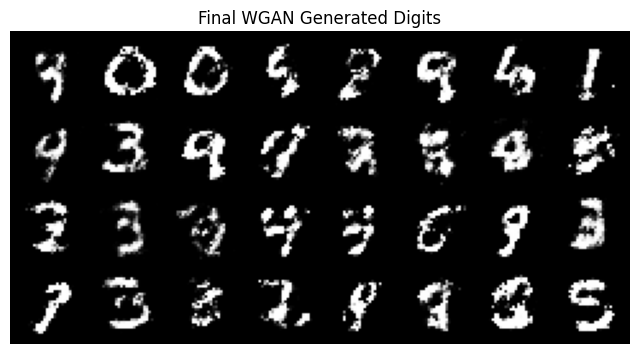

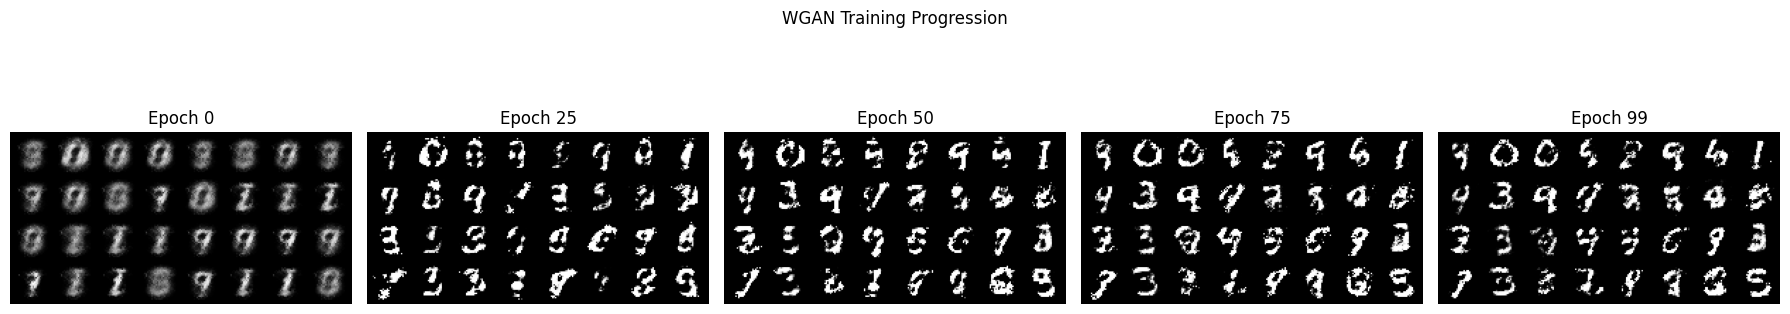

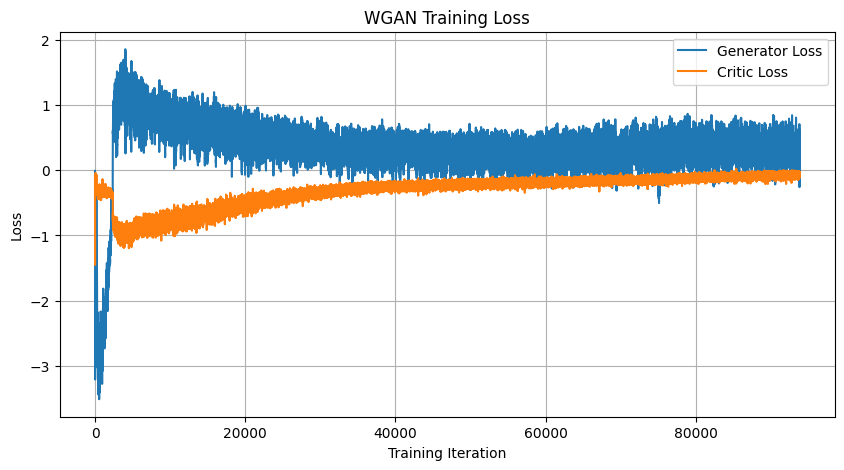

In [28]:
# It's noted that the `fixed_noise` for WGAN was re-initialized separately from the Standard GAN's.
# For a strictly comparative visualization across models, a single, shared `fixed_noise` should ideally be used.
# Create GIF


frames = []

for epoch in range(0, num_epochs, 5):

    path = f"generated_images/epoch_{epoch}.png"

    if os.path.exists(path):
        frames.append(imageio.imread(path))

last_path = f"generated_images/epoch_{num_epochs - 1}.png"

if os.path.exists(last_path):
    frames.append(imageio.imread(last_path))

imageio.mimsave(
    "wgan_training.gif",
    frames,
    duration=2.5,
)

print("Saved: wgan_training.gif")


# Final Generated Digits


with torch.no_grad():

    samples = generator(
        fixed_noise
    ).reshape(-1, 1, 28, 28)

    grid = utils.make_grid(
        samples,
        normalize=True,
        nrow=8,
    )

plt.figure(figsize=(8, 8))
plt.imshow(
    grid.permute(1, 2, 0).cpu(),
    cmap="gray",
)
plt.axis("off")
plt.title("Final WGAN Generated Digits")
plt.show()


# Epoch Comparison


comparison_epochs = [0, 25, 50, 75, 99]

fig, axes = plt.subplots(
    1,
    len(comparison_epochs),
    figsize=(18, 4),
)

for ax, epoch in zip(
    axes,
    comparison_epochs,
):

    path = f"generated_images/epoch_{epoch}.png"

    if os.path.exists(path):

        image = plt.imread(path)

        ax.imshow(image)
        ax.set_title(f"Epoch {epoch}")
        ax.axis("off")

plt.suptitle("WGAN Training Progression")
plt.tight_layout()
plt.show()

# Loss Curves


plt.figure(figsize=(10, 5))

plt.plot(
    generator_losses,
    label="Generator Loss",
)

plt.plot(
    critic_losses,
    label="Critic Loss",
)

plt.xlabel("Training Iteration")
plt.ylabel("Loss")
plt.title("WGAN Training Loss")
plt.legend()
plt.grid(True)

plt.show()

The critic loss in the WGAN gradually approaches zero during training. This indicates that the critic becomes increasingly unable to distinguish between real and generated samples, suggesting that the generator is learning a distribution that closely resembles the MNIST training data. Such behavior is generally considered a sign of stable convergence in Wasserstein GANs.



However, a critic loss close to zero does not necessarily imply superior image quality. While the WGAN exhibited stable training dynamics and produced several sharp digit samples, visual inspection shows that some generated digits remained incomplete or distorted. This highlights an important characteristic of generative models: loss values alone are insufficient for evaluating image quality, and qualitative inspection of generated samples remains essential.


Compared to the standard GAN, the WGAN demonstrated smoother and more interpretable loss behavior. Nevertheless, the standard GAN often generated more complete digit structures in this particular experiment, despite exhibiting noisier loss curves

### Comparison of two models

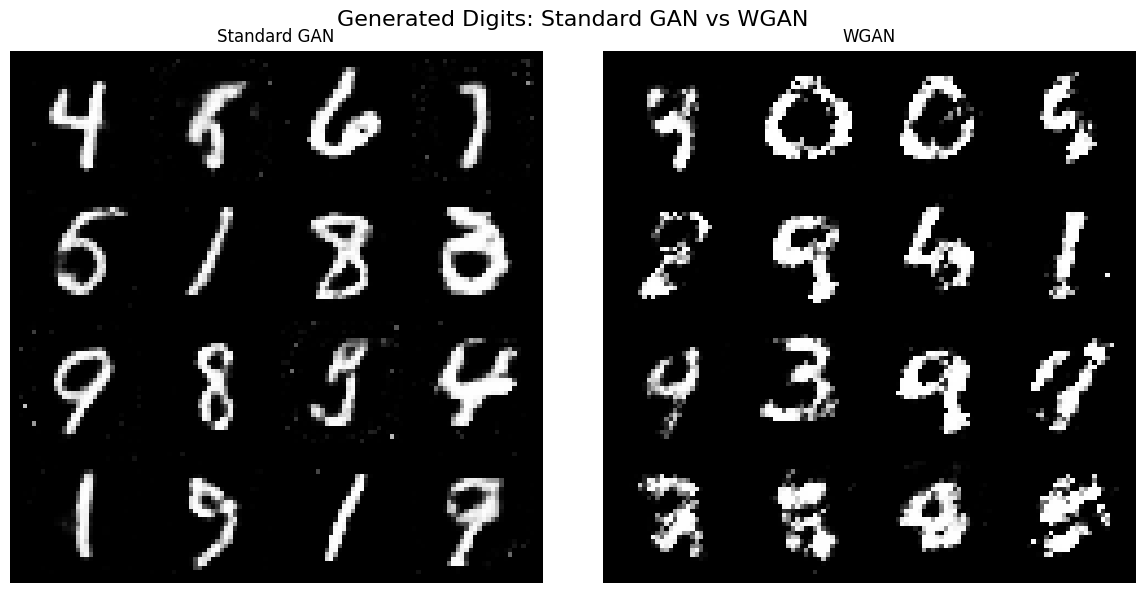

In [27]:
import torch
import os
from torchvision import utils
import matplotlib.pyplot as plt

# Assuming Generator class is defined and fixed_noise (from WGAN setup) is available
# Re-instantiate the Standard GAN's generator and load its saved state

# Create an instance of the Generator class (from the Standard GAN definition)
# Make sure the Generator class from the Standard GAN section is accessible.
# If it's not, you might need to re-run the Standard GAN Generator definition cell.
# For safety, let's assume it's available.

# Temporarily create a Standard GAN generator instance to load weights
standard_gan_generator = Generator().to(device)
standard_gan_generator.load_state_dict(torch.load("saved_models/generator.pth"))
standard_gan_generator.eval() # Set to evaluation mode

# Compare Standard GAN vs WGAN
with torch.no_grad():
    # Generate samples from the *loaded* Standard GAN generator
    gan_samples = (
        standard_gan_generator(fixed_noise)
        .reshape(-1, 1, 28, 28)
    )

    # Generate samples from the *current* WGAN generator (which is named 'generator')
    wgan_samples = (
        generator(fixed_noise) # 'generator' here refers to the WGAN generator
        .reshape(-1, 1, 28, 28)
    )

gan_grid = utils.make_grid(
    gan_samples[:16],
    normalize=True,
    nrow=4,
)

wgan_grid = utils.make_grid(
    wgan_samples[:16],
    normalize=True,
    nrow=4,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 6),
)

axes[0].imshow(
    gan_grid.permute(1, 2, 0).cpu(),
    cmap="gray",
)
axes[0].set_title("Standard GAN")
axes[0].axis("off")

axes[1].imshow(
    wgan_grid.permute(1, 2, 0).cpu(),
    cmap="gray",
)
axes[1].set_title("WGAN")
axes[1].axis("off")

plt.suptitle(
    "Generated Digits: Standard GAN vs WGAN",
    fontsize=16,
)

plt.tight_layout()
plt.show()


### Discussion on GAN vs WGAN

As an optional extension, a Wasserstein GAN (WGAN) was also implemented and compared against the standard GAN. The comparison should be interpreted with some caution because both models were not evaluated using the exact same fixed noise vectors. Ideally, the same latent input samples should be provided to both generators to ensure a perfectly fair comparison. Since this was not enforced in the current implementation, there is a small loss of generality in the qualitative comparison. I had less time left, so couldnt manage to rerun time-consuming training loop again. But, still we can make useful comments on comparison of their visual outputs difference.

The standard GAN generally produced digits that appeared more complete and recognizable as full handwritten numbers. However, some samples were slightly blurrier and had lower visual quality. In contrast, the WGAN often generated sharper strokes and stronger visual contrast, making some digits appear cleaner and more defined.

At the same time, the WGAN occasionally produced incomplete or distorted digits. While individual strokes were sometimes clearer, the overall structure of the digit was not always fully formed. This suggests that, in this implementation, the WGAN learned certain local digit features effectively but did not consistently generate complete digit shapes.

Overall, both approaches successfully learned the underlying MNIST digit distribution and generated realistic handwritten digits. The standard GAN produced more consistently complete digits, whereas the WGAN often generated sharper but occasionally less coherent samples. A more rigorous comparison would involve evaluating both models using identical latent vectors and potentially using a more advanced WGAN variant such as WGAN-GP, which replaces weight clipping with a gradient penalty and typically produces more stable training behavior.
